# The Ising Model of Neural Populations

<a target="_blank" href="https://colab.research.google.com/github/ANDA-NI-2026/ANDA-Day2-State-Space-Analysis/blob/main/02_ising_model_of_neural_populations/02_solutions.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Setup

### Import Libraries

Import the modules required for this session. Run all cells in this section before starting the exercises.

**Note**: This notebook uses a local libary that sits in the `/ssll` folder. Before we can import from it we must call `sys.path.insert(0, 'ssll')` to add that folder to the path where Python can find it.

In [ ]:
# When running in Google Colabm, uncomment these lines to download the ssll library
#!wget -O ssll.zip "https://uni-bonn.sciebo.de/s/MnQ7swMFGpneoYB/download"
#!unzip -q ssll.zip

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Import modules from local library /ssll
import sys
sys.path.insert(0, 'ssll')
import ssll
import synthesis
import transforms
import energies

### Utility Functions

The `utils` class below provides two plotting helpers used throughout the exercises. Run this cell once as part of Setup — you do not need to study the implementation.

In [ ]:
class utils:
    @staticmethod
    def plot_pattern_probs(p_t, N):
        """Bar chart of 2^N pattern probabilities."""
        patterns = transforms.enumerate_patterns(N)
        xlabels = [''.join(str(b) for b in pat) for pat in patterns]
        fig, ax = plt.subplots(figsize=(max(5, 2**N * 0.5), 3))
        ax.bar(range(2**N), p_t, color='steelblue')
        ax.set_xticks(range(2**N))
        ax.set_xticklabels(xlabels)
        ax.set_xlabel('Pattern')
        ax.set_ylabel('Probability')
        plt.tight_layout()

    @staticmethod
    def plot_pattern_comparison(p_list, labels, N):
        """Side-by-side bar chart comparing multiple pattern distributions."""
        patterns = transforms.enumerate_patterns(N)
        xlabels = [''.join(str(b) for b in pat) for pat in patterns]
        n = 2**N
        x = np.arange(n)
        w = 0.8 / len(p_list)
        offsets = (np.arange(len(p_list)) - (len(p_list) - 1) / 2) * w
        fig, ax = plt.subplots(figsize=(max(5, n * 0.7), 3))
        for p, label, offset in zip(p_list, labels, offsets):
            ax.bar(x + offset, p, w, label=label)
        ax.set_xticks(x)
        ax.set_xticklabels(xlabels)
        ax.set_xlabel('Pattern')
        ax.set_ylabel('Probability')
        ax.legend()
        plt.tight_layout()

When working with custom libraries, it is a good practice to test that it is working as expected. The cell below runs the code with some example paramerters and uses `assert` to verify the output is as expected. The cell should print: `"Setup OK: shapes (5, 6) (5, 8) (5, 10, 3)"`

In [ ]:
N_test, O_test, T_test, R_test = 3, 2, 5, 10

transforms.initialise(N_test, O_test)
theta_test = synthesis.generate_thetas(N_test, O_test, T_test)
p_test = np.array([transforms.compute_p(theta_test[t]) for t in range(T_test)])
spikes_test = synthesis.generate_spikes(p_test, R_test)
assert spikes_test.shape == (T_test, R_test, N_test), f"Expected (5,10,3), got {spikes_test.shape}"

print(f"Setup OK: shapes {theta_test.shape} {p_test.shape} {spikes_test.shape}")

Setup OK: shapes (5, 6) (5, 8) (5, 10, 3)


## Population Activity as Binary Words

In each time bin, every neuron is either active (1) or silent (0). Recording $N$ neurons simultaneously produces a binary vector of length $N$ at each time step. This is sometimes also called a spike word or population pattern. With $N$ neurons there are $2^N$ possible distinct patterns, ranging from the all-silent pattern (0000...) to the pattern in which every neuron fires (1111...).

In this exercise we will be working with the State-Space Analysis of Spike Correlations (SSLL) library developed by Hideaki Shimazaki and his team (https://github.com/shimazaki/ssll). The library generates and fits data using four key quantities — $N$, $O$, $T$, and $R$ — that together fully specify the experimental setup:

- **$N$**: number of neurons recorded simultaneously.
- **$O$**: model order. $O=2$ is the pairwise (Ising) model, which captures individual firing rates and all pairwise co-activation rates. $O=1$ is the independent model (firing rates only).
- **$T$**: number of time bins. In this exercise $T=1$, meaning we treat the population as stationary (one fixed distribution). (The next exercise notebook uses $T>1$ to track how the distribution changes over time.)
- **$R$**: number of trials. At each time bin the same stimulus or condition is repeated $R$ times, giving $R$ independent draws from the pattern distribution. More trials mean better-estimated statistics.

The function `synthesis.generate_thetas` draws a set of $D$ natural parameters $\theta$ from a Gaussian process. The latter is a model for smooth random trajectories in which nearby time bins tend to have similar parameter values, with the degree of smoothness controlled by a covariance function. For $T=1$ this reduces to a single draw from a Gaussian distribution. The function returns parameter trajectories of shape $(T, D)$. The function `transforms.compute_p` converts a single parameter vector $\theta_t$ into a probability distribution $p$ over all $2^N$ patterns — a vector of length $2^N$ where each entry is $P(\mathbf{x})$ for one binary word $x$. Given $p$, the function `transforms.compute_eta` computes the expectation parameters $\eta$: a vector of length $D$ containing the model-predicted marginal firing rates $\eta_i = E[x_i]$ and pairwise co-activation rates $\eta_{ij} = E[x_i x_j]$. Finally, `synthesis.generate_spikes` samples $R$ binary patterns from $p$ at each time bin, returning an array of shape $(T, R, N)$.

The natural parameters are organized as a vector of length $D$, where $$D = N + \frac{N(N-1)}{2}$$ for a second-order model. The first $N$ entries are biases (one per neuron) and the remaining $N(N-1)/2$ entries are pairwise coupling parameters (one per neuron pair). Together these parameters fully specify the Ising model probability distribution over spike patterns.

### Code Reference

| Code | Description                                                                                                               |
| :-- |:--------------------------------------------------------------------------------------------------------------------------|
| **`synthesis.generate_thetas(N, O, T)`** | Ground-truth natural parameters as Gaussian process, shape `(T, D)`                                                       |
| **`synthesis.generate_thetas(N, O, T, mu1=...)`** | `mu1`: prior mean of the Gaussian process for bias parameters (default -2.0); more negative shifts all firing rates lower |
| **`transforms.initialise(N, O)`** | Set up internal mapping matrices for N neurons, order O                                                                   |
| **`transforms.compute_D(N, O)`** | Total number of natural parameters D                                                                                      |
| **`transforms.compute_p(theta_t)`** | Probability distribution over all 2^N patterns for one time bin's parameter vector; shape `(2^N,)`                        |
| **`p = np.array([transforms.compute_p(theta[t]) for t in range(T)])`** | Stack per-time-bin distributions; `p` has shape `(T, 2^N)` — use `p[t]` (e.g. `p[0]`) to select one time bin            |
| **`transforms.compute_eta(p[t])`** | Expectation parameters $\eta$ from one time bin's `p[t]`: marginal rates `[:N]` and pairwise rates `[N:]`; shape `(D,)`  |
| **`synthesis.generate_spikes(p, R)`** | Sample R spike patterns per time bin from p; returns shape `(T, R, N)`                                                    |

### Exercises

**Example:** Generate parameters and example spike trains for `N=3`, `O=2`, `T=1`, `R=200`. Print shapes of `theta`, `p`, and sampled spikes `spikes`.

In [ ]:
N, O, T, R = 3, 2, 1, 200

transforms.initialise(N, O)
theta = synthesis.generate_thetas(N, O, T)
p = np.array([transforms.compute_p(theta[t]) for t in range(T)])
spikes = synthesis.generate_spikes(p, R)

print('theta shape:', theta.shape)
print('p shape:    ', p.shape)
print('spikes shape:', spikes.shape)

theta shape: (1, 6)
p shape:     (1, 8)
spikes shape: (1, 200, 3)


**Exercise:** Change `N` to 4. Print `transforms.compute_D(4, O)`, which outputs the number of natural parameters $D$. Verify it equals $N + N(N-1)/2$.

In [ ]:
N4 = 4

transforms.initialise(N4, O)
D4 = transforms.compute_D(N4, O)

print('D =', D4, '  expected:', N4 + N4*(N4-1)//2)

D = 10   expected: 10


**Exercise:** Using `N=3`, set `R=500`. Compute the model's expected firing rates with `transforms.compute_eta(p[0])[:N]` and compare them to the empirical rates obtained from the sampled spike trains (Hint: `spikes.mean(axis=(0, 1))`). They should be close.

In [ ]:
N, O, T, R = 3, 2, 1, 500

transforms.initialise(N, O)
theta = synthesis.generate_thetas(N, O, T)
p = np.array([transforms.compute_p(theta[t]) for t in range(T)])
spikes = synthesis.generate_spikes(p, R)
expected_rates = np.array(transforms.compute_eta(p[0]))[:N]

print('Expected rates (model): ', expected_rates.round(3))
print('Empirical firing rates:  ', spikes.mean(axis=(0, 1)).round(3))

Expected rates (model):  [0.087 0.106 0.132]
Empirical firing rates:   [0.094 0.116 0.102]


**Exercise:** Print the $2^N$ pattern probabilities `p[0]` and verify they sum to 1. Then call `utils.plot_pattern_probs(p[0], N)` to visualise the distribution.

Pattern probabilities: [0.7087 0.0667 0.0872 0.1046 0.0058 0.0136 0.0123 0.0011]
Sum: 1.0


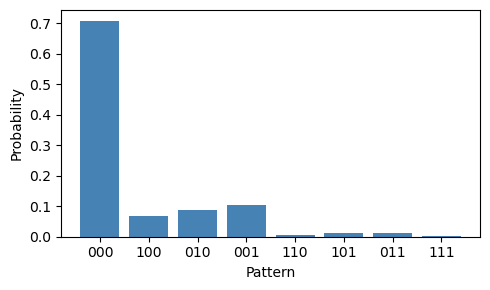

In [ ]:
print('Pattern probabilities:', p[0].round(4))
print('Sum:', p[0].sum())

utils.plot_pattern_probs(p[0], N)

**Exercise:** Plot `spikes[0, :30, :].T` of the first 30 trials as a 2D binary image to visualize 30 spike patterns. Set xlabel='Trial', ylabel='Neuron'. You can use `imshow(...,aspect='auto', cmap='binary', interpolation='none')` of matplotlib to do this.

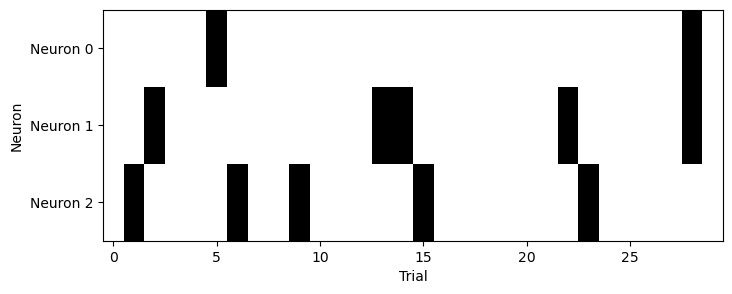

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.imshow(spikes[0, :30, :].T, aspect='auto', cmap='binary', interpolation='none')
ax.set_xlabel('Trial')
ax.set_ylabel('Neuron')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Neuron 0', 'Neuron 1', 'Neuron 2']);

**Exercise:** The parameter `mu1` is the prior mean of the Gaussian process from which bias parameters are drawn (default -2.0). Change `mu1` to `-4.0` in `synthesis.generate_thetas` and compare the empirical firing rates to the default case. Why do all three neurons fire less often?

In [ ]:
theta_low = synthesis.generate_thetas(N, O, T, mu1=-4.0)
p_low = np.array([transforms.compute_p(theta_low[t]) for t in range(T)])
spikes_low = synthesis.generate_spikes(p_low, R)
print('Empirical rates (mu1=-4.0):', spikes_low.mean(axis=(0, 1)).round(3))

Empirical rates (mu1=-4.0): [0.02  0.016 0.022]


## The Ising Model and Natural Parameters

The Ising model assigns a probability to each of the $2^N$ binary patterns $x$ based on how much each neuron fires and how often pairs of neurons fire together. Each bias $\theta_i$ contributes $\theta_i \cdot x_i$ to a score, thus adding weight when neuron $i$ fires ($x_i = 1$) and zero when it is silent. Each coupling $\theta_{ij}$ contributes $\theta_{ij} \cdot x_i x_j$, likewise adding weight only when both neurons $i$ and $j$ fire simultaneously. The probability of a pattern is proportional to the exponential of this score:

$$P(x) \propto \exp\!\Bigl(\sum_i \theta_i x_i + \sum_{i<j} \theta_{ij} x_i x_j\Bigr)$$

The exponential is the natural choice: probabilities must be positive (the exponential is always positive), and independent contributions should multiply. If all couplings are zero, $\exp\!\bigl(\sum_i \theta_i x_i\bigr)$ factorizes into a product of per-neuron terms $\prod_i \exp(\theta_i x_i)$, exactly as expected for independent neurons. Dividing by the sum over all $2^N$ patterns normalizes the distribution.

First-order parameters $\theta_i$ are biases: a large negative value makes neuron $i$ unlikely to fire in isolation, while a positive value increases its marginal firing probability. Second-order parameters $\theta_{ij}$ are couplings: a positive value means neurons $i$ and $j$ tend to fire together more than expected from their individual rates, while a negative value introduces anticorrelation.

The $D$ natural parameters are arranged as a vector with $N$ biases first ($\theta_1, \ldots, \theta_N$), followed by $N(N-1)/2$ pairwise couplings in lexicographic order ($\theta_{12}, \theta_{13}, \ldots, \theta_{(N-1)N}$). The function `transforms.compute_p` evaluates this for a given `theta` and returns a vector of $2^N$ probabilities, one per pattern, ordered to match the rows of `transforms.enumerate_patterns(N)`.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`theta[:N]`** | First-order parameters (biases), one per neuron |
| **`theta[N:]`** | Second-order parameters (couplings), one per neuron pair |
| **`transforms.compute_p(theta)`** | Returns $2^N$ pattern probabilities for `theta`; order matches `enumerate_patterns(N)` |
| **`transforms.enumerate_patterns(N)`** | Matrix of all 2^N binary patterns, shape `(2^N, N)` |

### Exercises

**Example:** For `N=2`, define the vector $\theta$ manually and print all 4 patterns with their probabilities. Check how the choice of $\theta$ affects $p$.

In [ ]:
N, O = 2, 2

transforms.initialise(N, O)
theta_ex = np.array([-1.0, -1.0, 0.0])
p_ex = transforms.compute_p(theta_ex)
patterns = transforms.enumerate_patterns(N)

for i in range(len(p_ex)):
    print(f'Pattern {patterns[i]}: p = {p_ex[i]:.4f}')

Pattern [0 0]: p = 0.5344
Pattern [1 0]: p = 0.1966
Pattern [0 1]: p = 0.1966
Pattern [1 1]: p = 0.0723


**Exercise:** Set `theta_ex = np.array([-3.0, 0.0, 0.0])`. Which neuron is less likely to fire? Confirm by calculating the probabilities of all patterns and then summing the probability of all patterns where neuron 0 fires and separately where neuron 1 fires.

In [ ]:
theta_ex = np.array([-3.0, 0.0, 0.0])

p_ex = transforms.compute_p(theta_ex)
patterns = transforms.enumerate_patterns(N)
p_n0 = p_ex[patterns[:, 0] == 1].sum()
p_n1 = p_ex[patterns[:, 1] == 1].sum()

print('P(neuron 0 fires):', p_n0.round(4))
print('P(neuron 1 fires):', p_n1.round(4))

P(neuron 0 fires): 0.0474
P(neuron 1 fires): 0.5


**Exercise:** Set a strong positive coupling: `theta_coupled = np.array([-1.0, -1.0, 2.0])`. Compare $P(\textrm{both neurons fire})$ to the uncoupled case `theta_uncoupled = np.array([-1.0, -1.0, 0.0])`. Store the two probability distributions as `p_uncoupled` and `p_coupled` — the next exercise reuses these names. Then call `utils.plot_pattern_comparison([p_uncoupled, p_coupled], ['zero coupling', 'positive coupling'], N)` to compare the full distributions side by side.

P(both fire) with coupling:    0.3655
P(both fire) without coupling: 0.0723


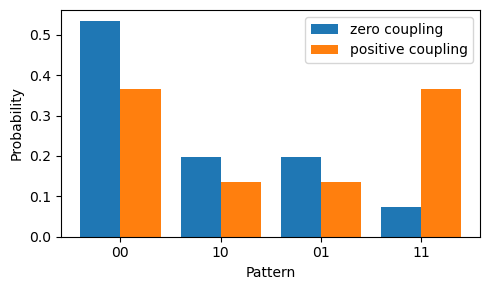

In [ ]:
theta_coupled = np.array([-1.0, -1.0, 2.0])
theta_uncoupled = np.array([-1.0, -1.0, 0.0])

p_coupled = transforms.compute_p(theta_coupled)
p_uncoupled = transforms.compute_p(theta_uncoupled)
patterns = transforms.enumerate_patterns(N)
both_idx = (patterns[:, 0] == 1) & (patterns[:, 1] == 1)

print('P(both fire) with coupling:   ', p_coupled[both_idx][0].round(4))
print('P(both fire) without coupling:', p_uncoupled[both_idx][0].round(4))
utils.plot_pattern_comparison([p_uncoupled, p_coupled], ['zero coupling', 'positive coupling'], N)

**Exercise:** Set `theta_neg = np.array([-1.0, -1.0, -2.0])` (negative coupling). Print $p(1,1)$ and $p(0,0)$. Then call `utils.plot_pattern_comparison([p_neg, p_uncoupled, p_coupled], ['negative', 'zero', 'positive'], N)` to compare all three coupling scenarios side by side. How does anticorrelation change the pattern distribution?

P(both fire):     0.0104
P(both silent):   0.5701


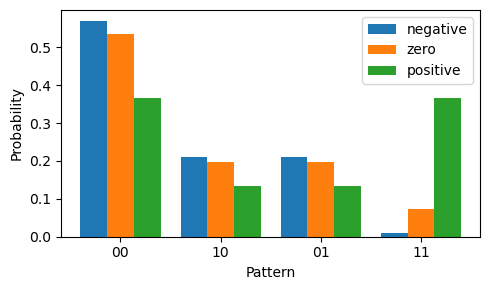

In [ ]:
theta_neg = np.array([-1.0, -1.0, -2.0])

p_neg = transforms.compute_p(theta_neg)
patterns = transforms.enumerate_patterns(N)
neither_fire_idx = (patterns[:, 0] == 0) & (patterns[:, 1] == 0)
both_fire_idx = (patterns[:, 0] == 1) & (patterns[:, 1] == 1)
p_silent = p_neg[neither_fire_idx][0]
p_both = p_neg[both_fire_idx][0]

print('P(both fire):    ', p_both.round(4))
print('P(both silent):  ', p_silent.round(4))
utils.plot_pattern_comparison([p_neg, p_uncoupled, p_coupled], ['negative', 'zero', 'positive'], N)

**Exercise:** Verify that `transforms.compute_p(theta)` always produces a valid probability distribution by checking that the probabilities sum to 1.0 for three different theta vectors.

In [ ]:
for theta_test in [
    np.array([0.0, 0.0, 0.0]),
    np.array([-2.0, 1.0, 3.0]),
    np.array([0.5, -0.5, -1.5]),
]:
    p_test = transforms.compute_p(theta_test)
    print(f'sum(p) = {p_test.sum():.8f}')

sum(p) = 1.00000000
sum(p) = 1.00000000
sum(p) = 1.00000000


## Fitting the Model with the EM Algorithm

Given observed spike patterns, SSLL finds the natural parameters $\theta$ that best explain the data using an expectation-maximization (EM) algorithm. The algorithm alternates two steps until convergence:

- **E-step** (Expectation): Estimate where $\theta$ most likely was at each time bin, given the spike data and the current assumption about how $\theta$ evolves over time. The result is not a single value but a *posterior*, i.e., a probability distribution over $\theta$ values that are consistent with the observed spikes. A broad posterior means the data leave many $\theta$ values plausible; a narrow one means the spikes pin down $\theta$ tightly. Technically, this uses a Kalman filter (forward pass) and a backward smoother to propagate information across time bins.

- **M-step** (Maximization): Update the assumption about how much $\theta$ is allowed to change from one time bin to the next (the state noise covariance $Q$), choosing the value that makes the observed data most probable under the current posterior.

The function `ssll.run` runs this loop until convergence and returns an `EMData` container.

The container's primary result is `emd.theta_s`, the smoothed *posterior mean*, shape `(T, D)`. The posterior mean is the average of the posterior distribution — the single $\theta$ value that best summarizes what the spike data support at each time bin. The attribute `emd.eta_s` holds the corresponding expectation parameters: model-predicted firing rates and pairwise co-firing rates.

The log marginal likelihood `emd.mll` summarizes how well the model fits the data as a single number. The list `emd.mll_list` records this value at each EM iteration; convergence is visible as a plateau.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`ssll.run(spikes, order)`** | Fit the model; returns EMData container |
| **`ssll.run(spikes, order, EM_Info=False)`** | `EM_Info=False` suppresses the per-iteration progress bar and final likelihood printout |
| **`emd.theta_s`** | Smoothed natural parameters, shape `(T, D)` |
| **`emd.eta_s`** | Smoothed expectation parameters, shape `(T, D)` |
| **`emd.sigma_s`** | Smoothed posterior covariances, shape `(T, D, D)` |
| **`emd.mll`** | Final log marginal likelihood |
| **`emd.mll_list`** | Log marginal likelihood at each EM iteration |
| **`emd.N, emd.D, emd.T`** | Number of neurons, parameters, time bins |

### Exercises

**Example:** Generate ground truth data (spikes) following a Gaussian process and fit a model with three neurons to it (`N=3`, `O=2`, `T=1`, `R=300`). Print key container attributes and compare inferred theta to ground truth.

In [ ]:
N, O, T, R = 3, 2, 1, 300

transforms.initialise(N, O)
theta = synthesis.generate_thetas(N, O, T)
p = np.array([transforms.compute_p(theta[t]) for t in range(T)])
spikes = synthesis.generate_spikes(p, R)
emd = ssll.run(spikes, order=O, EM_Info=False)

print('N =', emd.N, '  D =', emd.D, '  T =', emd.T)
print('Inferred \u03b8:', emd.theta_s[0].round(3))
print('True \u03b8:    ', theta[0].round(3))

N = 3   D = 6   T = 1
Inferred θ: [-2.157 -1.822 -1.747  0.11  -0.435 -0.232]
True θ:     [-2.228 -1.727 -1.816  0.087 -0.298 -0.03 ]


**Exercise:** Print the mean squared error between `emd.theta_s[0]` and `theta[0]`.

In [ ]:
mse = np.mean((emd.theta_s[0] - theta[0])**2)

print(f'MSE = {mse:.4f}')

MSE = 0.0131


**Exercise:** Increase R to 1000 and refit. How does the MSE change?

In [ ]:
spikes_large = synthesis.generate_spikes(p, 1000)
emd_large = ssll.run(spikes_large, order=O, EM_Info=False)
mse_large = np.mean((emd_large.theta_s[0] - theta[0])**2)

print(f'MSE with R=1000: {mse_large:.4f}')

MSE with R=1000: 0.0775


**Exercise:** Plot `emd.mll_list` to visualize EM convergence. The values should increase monotonically and plateau.

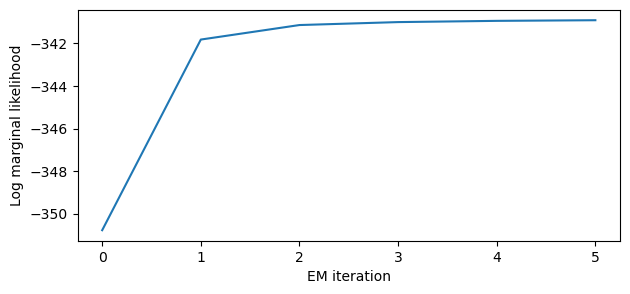

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(emd.mll_list)

ax.set_xlabel('EM iteration')
ax.set_ylabel('Log marginal likelihood')

**Exercise:** Decrease R to 30 and refit. Inspect how the inferred theta compares to ground truth.

In [ ]:
spikes_tiny = synthesis.generate_spikes(p, 30)
emd_tiny = ssll.run(spikes_tiny, order=O, EM_Info=False)

print(f'MSE with R=30:  {np.mean((emd_tiny.theta_s[0] - theta[0])**2):.4f}')
print('Inferred:', emd_tiny.theta_s[0].round(3))
print('True:    ', theta[0].round(3))

MSE with R=30:  1.3121
Inferred: [-2.861 -1.342 -1.912  1.898 -1.15  -1.849]
True:     [-2.228 -1.727 -1.816  0.087 -0.298 -0.03 ]


**Exercise:** Print `emd.sigma_s.shape`. Then print `np.sqrt(emd.sigma_s[0, 0, 0])`: the posterior standard deviation of the first parameter. How does this compare to the estimation error?

In [ ]:
print('sigma_s shape:', emd.sigma_s.shape)
std_first = np.sqrt(emd.sigma_s[0, 0, 0])
err_first = abs(emd.theta_s[0, 0] - theta[0, 0])
print(f'Posterior std (\u03b8\u2081): {std_first:.4f}')
print(f'Actual error:       {err_first:.4f}')

sigma_s shape: (1, 6, 6)
Posterior std (θ₁): 0.1682
Actual error:       0.0708


## Expectation Parameters and Population Statistics (Optional)

The expectation parameters $\eta$ are the expected values of the sufficient statistics under the model: $\eta^1_{i} = E[x_i]$ is the marginal firing probability of neuron $i$, and $\eta^2_{ij} = E[x_i \cdot x_j]$ is the joint firing probability of neurons i and j. The EM algorithm ensures that the model's expectation parameters match the empirical statistics at convergence. Thus `emd.eta_s[t, :N]` equals the trial-averaged firing rates, and `emd.eta_s[t, N:]` equals the empirical co-firing rates.

The distinction between natural parameters theta and expectation parameters eta is fundamental to exponential family models. The natural parameters determine the shape of the distribution in an abstract algebraic sense, while the expectation parameters directly correspond to observable statistics of the data. Both representations are useful: $\theta$ is informative of the coupling structure, and $\eta$ directly relates to firing rates and correlations the model predicts from a given realization of that model.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`emd.eta_s[:, :N]`** | Smoothed firing rates, shape `(T, N)` |
| **`emd.eta_s[:, N:]`** | Smoothed pairwise co-firing rates, shape `(T, N*(N-1)//2)` |
| **`spikes.mean(axis=(0, 1))`** | Empirical firing rates |
| **`(spikes[:, :, i] * spikes[:, :, j]).mean()`** | Empirical co-firing rate of neurons i and j |

### Exercises

*Run the cell below only if you are starting here without having completed Section 3; it regenerates `spikes`, `theta`, `p`, and the fitted `emd`.*

In [ ]:
# Realign: run this cell if you are starting Section 4 without having run Section 3
# Sets up: N, O, T, R, theta, p, spikes, emd
N, O, T, R = 3, 2, 1, 300

transforms.initialise(N, O)
theta = synthesis.generate_thetas(N, O, T)
p = np.array([transforms.compute_p(theta[t]) for t in range(T)])
spikes = synthesis.generate_spikes(p, R)
emd = ssll.run(spikes, order=O, EM_Info=False)

print(f'Realign OK — N={N}, T={T}, R={R}, emd fitted')

Realign OK — N=3, T=1, R=300, emd fitted


**Example:** Compare inferred firing rates `emd.eta_s[0, :N]` with the empirical rates.

In [ ]:
emp_rates = spikes.mean(axis=(0, 1))

print('Empirical rates:  ', emp_rates.round(3))
print('Inferred \u03b7\u2081:      ', emd.eta_s[0, :N].round(3))

Empirical rates:   [0.113 0.133 0.103]
Inferred η₁:       [0.114 0.133 0.104]


**Exercise:** Print `emd.eta_s[0, N:]` (pairwise co-firing rates). For pairs (0,1), (0,2), (1,2), compute the empirical $p(x_i=1, x_j=1)$ from the spike data and compare.

In [ ]:
print('Inferred \u03b7\u2082:', emd.eta_s[0, N:].round(3))

for i, j in [(0, 1), (0, 2), (1, 2)]:
    emp = (spikes[:, :, i] * spikes[:, :, j]).mean()
    print(f'Empirical P(x{i}=1, x{j}=1): {emp:.3f}')

Inferred η₂: [0.013 0.012 0.01 ]
Empirical P(x0=1, x1=1): 0.013
Empirical P(x0=1, x2=1): 0.013
Empirical P(x1=1, x2=1): 0.010


**Exercise:** Refit with order=1 (independent model) and store the result as `emd_ind`. Do the inferred firing rates `emd_ind.eta_s[0, :N]` match those of the pairwise model?

In [ ]:
emd_ind = ssll.run(spikes, order=1, EM_Info=False)

print('Independent model \u03b7\u2081:', emd_ind.eta_s[0, :N].round(3))
print('Pairwise model \u03b7\u2081:   ', emd.eta_s[0, :N].round(3))

Independent model η₁: [0.113 0.133 0.104]
Pairwise model η₁:    [0.114 0.133 0.104]


**Exercise:** Compare the bias parameters emd.theta_s[0, :N] (pairwise) and emd_ind.theta_s[0, :N] (independent). Why might they differ even though both models match the firing rates?

*Hint*: in the pairwise model each bias must compensate for the coupling's contribution to the marginal firing rate. A positive coupling between neurons i and j raises their joint probability, which in turn raises neuron i's marginal rate; the bias $\theta_i$ is therefore shifted more negative to keep the marginal rate at the empirical level. The independent model has no such compensation.

In [ ]:
print('Pairwise \u03b8\u2081:    ', emd.theta_s[0, :N].round(3))
print('Independent \u03b8\u2081: ', emd_ind.theta_s[0, :N].round(3))

Pairwise θ₁:     [-2.027 -1.809 -2.111]
Independent θ₁:  [-2.056 -1.871 -2.158]


**Exercise:** Create a dataset with a known strong positive coupling (`theta = [-1.5, -1.5, -1.5, 2.0, 0.0, 0.0]`) and fit the model; store the result as `emd_strong`. Verify that `emd_strong.theta_s[0, N]` is positive and that `emd_strong.eta_s[0, N]` is higher than for uncoupled neurons.

 *Hint:* For `eta_s`, the first index `[0]` selects the first (and only) time bin (`T=1`). `[N]` selects index `N=3`, which is the first pairwise parameter — the coupling between neurons 0 and 1. This is because `[:N]` holds biases (individual neurons) and `[N:]` holds pairwise parameters.

In [ ]:
N, O, T, R = 3, 2, 1, 300

transforms.initialise(N, O)
theta_strong_gt = np.array([-1.5, -1.5, -1.5, 2.0, 0.0, 0.0]).reshape(1, -1)
p_strong = np.array([transforms.compute_p(theta_strong_gt[t]) for t in range(T)])
spikes_strong = synthesis.generate_spikes(p_strong, R)
emd_strong = ssll.run(spikes_strong, order=O, EM_Info=False)

print('Coupling \u03b8\u2081\u2082:       ', emd_strong.theta_s[0, N].round(3))
print('Co-firing rate \u03b7\u2081\u2082: ', emd_strong.eta_s[0, N].round(3))
print('Baseline \u03b7\u2081\u2082:       ', emd.eta_s[0, N].round(3))

Coupling θ₁₂:        1.926
Co-firing rate η₁₂:  0.209
Baseline η₁₂:        0.013


## Model Comparison: Independent vs Pairwise Interactions (Optional)

The `energies` module computes thermodynamic quantities that measure how much of the population's statistical structure is captured by pairwise interactions. The entropy $S$ of a probability distribution measures its variability: a uniform distribution over all $2^N$ patterns has maximum entropy, while a distribution concentrated on one pattern has zero entropy. The entropy $S_1$ of the independent model is always at least as large as $S_2$ of the pairwise model, because pairwise interactions constrain which patterns are more likely.

The entropy ratio $S_{\textrm{ratio}} = (S1 - S2) / S1$ measures what fraction of the independent model's uncertainty is explained by pairwise coupling. When $S_{\textrm{ratio}}$ is near zero, pairwise interactions add little beyond the marginal firing rates. When $S_{\textrm{ratio}}$ is large, pairwise structure accounts for a substantial fraction of the population variability. This quantity has been used empirically to assess how close neural populations are to a critical state.

The KL divergence quantifies the information cost of ignoring pairwise interactions: it measures how much the independent model distribution differs from the pairwise model distribution. Large KL divergence means the two models make very different predictions about pattern probabilities.

### Code Reference

| Code | Description |
| :-- | :-- |
| **`energies.get_energies(emd)`** | Compute and attach thermodynamic quantities to the container |
| **`emd.S1`** | Entropy of independent model, shape `(T,)` |
| **`emd.S2`** | Entropy of pairwise model, shape `(T,)` |
| **`emd.S_ratio`** | Entropy ratio (S1-S2)/S1, shape `(T,)` |
| **`emd.dkl`** | KL divergence from independent to pairwise model, shape `(T,)` |
| **`emd.llk1`, `emd.llk2`** | Log-likelihoods of independent and pairwise models |

### Exercises

*Run the cell below only if you are starting here without having completed Sections 3 and 4; it regenerates `spikes`, `theta`, `p`, `emd`, `emd_ind`, and `emd_strong`.*

In [ ]:
# Realign: run this cell if you are starting Section 5 without having run Sections 3 and 4
# Sets up: N, O, T, R, theta, p, spikes, emd, emd_ind, emd_strong
N, O, T, R = 3, 2, 1, 300

transforms.initialise(N, O)
theta = synthesis.generate_thetas(N, O, T)
p = np.array([transforms.compute_p(theta[t]) for t in range(T)])
spikes = synthesis.generate_spikes(p, R)
emd = ssll.run(spikes, order=O, EM_Info=False)
emd_ind = ssll.run(spikes, order=1, EM_Info=False)
transforms.initialise(N, O)  # ssll.run(order=1) leaves transforms in O=1 state; re-initialise for O=2
theta_strong_gt = np.array([-1.5, -1.5, -1.5, 2.0, 0.0, 0.0]).reshape(1, -1)
p_strong = np.array([transforms.compute_p(theta_strong_gt[t]) for t in range(T)])
spikes_strong = synthesis.generate_spikes(p_strong, R)
emd_strong = ssll.run(spikes_strong, order=O, EM_Info=False)

print(f'Realign OK — emd, emd_ind, emd_strong ready')

Realign OK — emd, emd_ind, emd_strong ready


**Example:** Compute thermodynamic quantities for the fitted model and print `S1`, `S2`, and the entropy ratio.

In [ ]:
energies.get_energies(emd)
print(f'S\u2081 (independent) = {emd.S1[0]:.4f}')
print(f'S\u2082 (pairwise)    = {emd.S2[0]:.4f}')
print(f'S_ratio          = {emd.S_ratio[0]:.4f}')

S₁ (independent) = 1.1515
S₂ (pairwise)    = 1.1485
S_ratio          = 0.0026


**Exercise:** Print `emd.dkl[0]`. Does a higher `S_ratio` correspond to a higher KL divergence?

In [ ]:
print(f'KL divergence: {emd.dkl[0]:.4f}')

KL divergence: 0.0030


**Exercise:** Compute energies for `emd_strong` (the strongly coupled model). Compare `S_ratio` to the weakly coupled case.

In [ ]:
energies.get_energies(emd_strong)
print(f'Weak coupling   S_ratio: {emd.S_ratio[0]:.4f}')
print(f'Strong coupling S_ratio: {emd_strong.S_ratio[0]:.4f}')

Weak coupling   S_ratio: 0.0026
Strong coupling S_ratio: 0.0646


**Exercise:** Compute energies for `emd_ind` (the `order=1` model fitted in the Expectation Parameters section above). What is `S_ratio` for a model fitted without pairwise terms?

In [ ]:
energies.get_energies(emd_ind)
print(f'Independent model S_ratio: {emd_ind.S_ratio[0]:.4f}')

Independent model S_ratio: -0.0000


**Exercise:** Print `emd.llk2 - emd.llk1`. Does the pairwise model always fit the data better?

In [ ]:
print(f'LL gain (pairwise vs independent): {emd.llk2 - emd.llk1}')
print(f'LL gain (strong coupling):         {emd_strong.llk2 - emd_strong.llk1}')

LL gain (pairwise vs independent): [1.03509562]
LL gain (strong coupling):         [35.61921265]


**Exercise:** Generate a dataset where all couplings are exactly zero (`theta = [-1.5, -1.5, -1.5, 0.0, 0.0, 0.0]`). Fit the pairwise model and verify that `S_ratio` is close to zero.

In [ ]:
theta_ind_gt = np.array([-1.5, -1.5, -1.5, 0.0, 0.0, 0.0]).reshape(1, -1)
p_ind = np.array([transforms.compute_p(theta_ind_gt[0])])
spikes_ind = synthesis.generate_spikes(p_ind, R)
emd_ind_data = ssll.run(spikes_ind, order=O, EM_Info=False)
energies.get_energies(emd_ind_data)

print(f'True independent data S_ratio: {emd_ind_data.S_ratio[0]:.4f}')

True independent data S_ratio: 0.0004


Session 2 extends this framework to time-varying populations: the natural parameters $\theta_t$ evolve over time, and state-space smoothing is used to track them dynamically.